# Notebook para el Copiloto Virtual

### Elaborado por Alvaro Zambrana Sejas
### Universidad Mayor de San Simón
### 2024

Entrenamiento local con YOLO utilizando un dataset personalizado.

Requirements:
- Anaconda
- Python 3.10 

Configurar:
```
conda create -n copiloto-virtual python=3.10
conda activate copiloto-virtual
``` 

In [4]:
!python --version

Python 3.10.16


In [5]:
!nvidia-smi

Thu Mar 13 17:54:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.60                 Driver Version: 572.60         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
| 36%   36C    P8             28W /  350W |    1808MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Configurar el entorno

In [6]:
import os
%cd ..

HOME = os.getcwd()
parent_dir = os.path.dirname(HOME)
print(f'HOME: {HOME}')

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
HOME: C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [30]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124


In [31]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.5.1%2Bcu124-cp310-cp310-win_amd64.whl (2510.7 MB)
  Using cached https://download.pytorch.org/whl/cu124/torchvision-0.20.1%2Bcu124-cp310-cp310-win_amd64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu124/torchaudio-2.5.1%2Bcu124-cp310-cp310-win_amd64.whl (4.1 MB)


In [7]:
# reiniciar el kernel después de ejecutar la celda anterior

import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.get_device_name(0))
print(torch.cuda.current_device())
print(torch.__version__)

True
NVIDIA GeForce RTX 3090
0
2.5.1+cu124


In [5]:
!pip uninstall -y ultralytics

Found existing installation: ultralytics 8.1.34
Uninstalling ultralytics-8.1.34:
  Successfully uninstalled ultralytics-8.1.34


In [6]:
!pip install -q git+https://github.com/THU-MIG/yolov10.git

In [11]:
!pip install huggingface_hub

In [12]:
!yolo -version

8.1.34


# Inferencia utilizando el model de YOLOv10 pre-entrenado

In [9]:
!cd {HOME}

!yolo task=detect mode=predict conf=0.25 save=True model={HOME}/weights/yolov10n.pt source="{HOME}\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg" device=0 project="resultados\\YOLOv10" name="prueba_inferencia" exist_ok=True

Ultralytics YOLOv8.1.34 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
YOLOv10n summary (fused): 285 layers, 2762608 parameters, 63840 gradients, 8.6 GFLOPs

image 1/1 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg: 640x640 1 0, 2 2s, 1 5, 15.0ms
Speed: 5.0ms preprocess, 15.0ms inference, 75.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to resultados\YOLOv10\prueba_inferencia
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\ultralytics\nn\tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cp

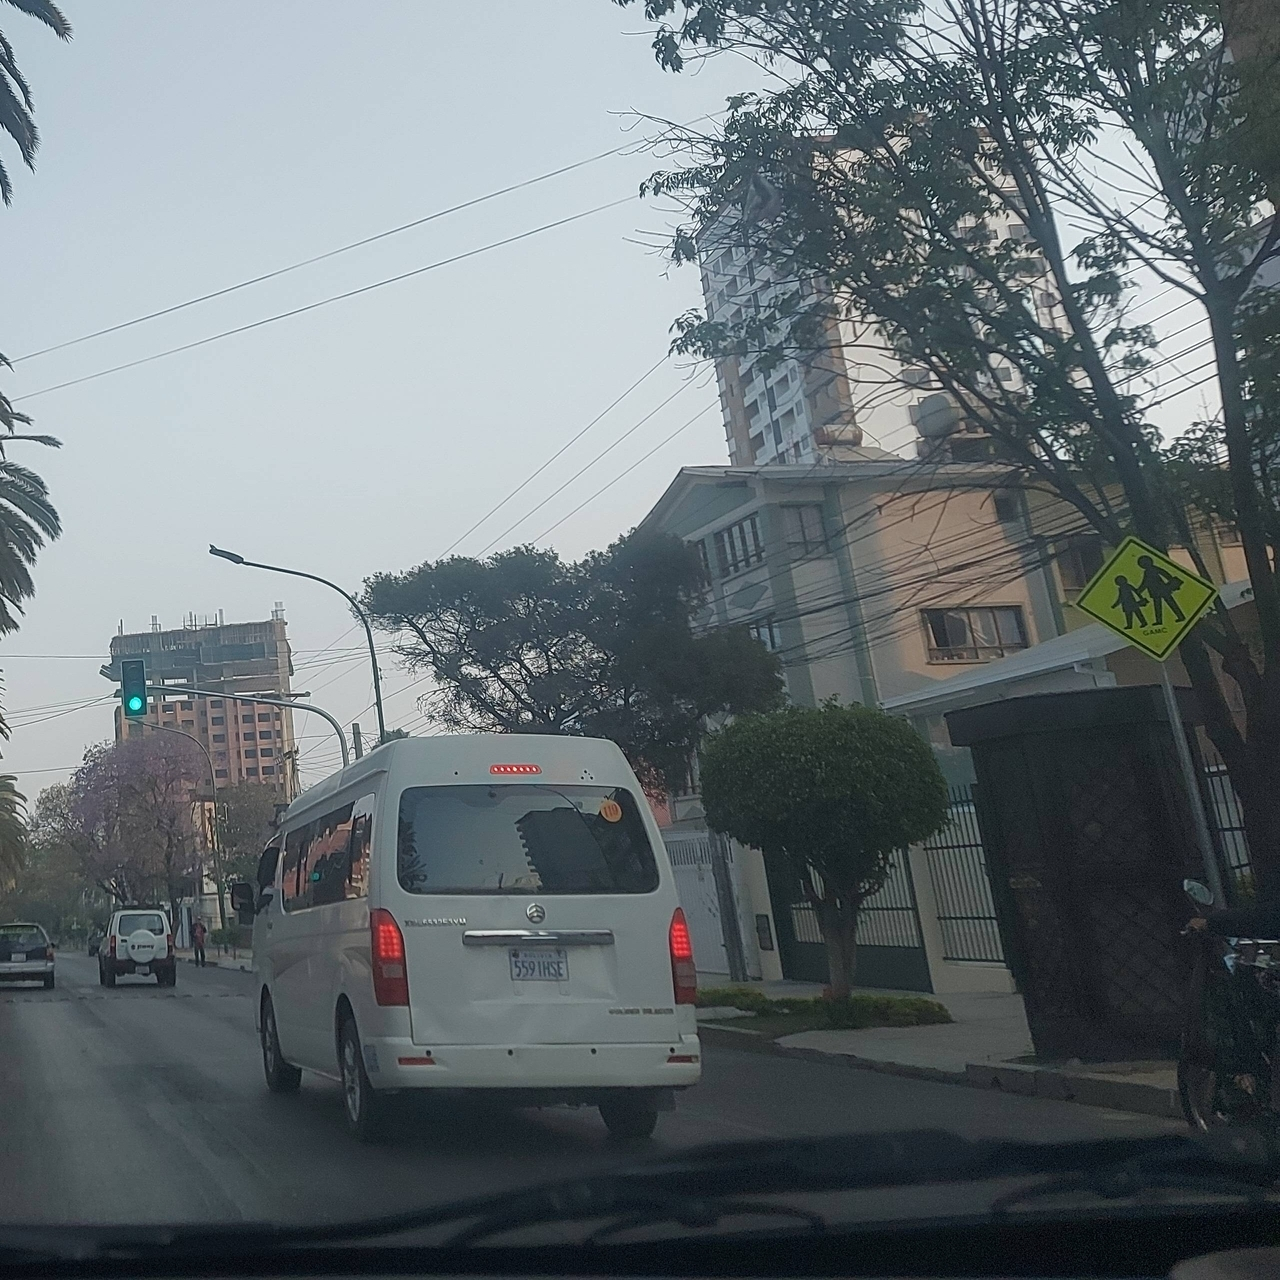

In [10]:
from IPython.display import Image

Image(filename=f".\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

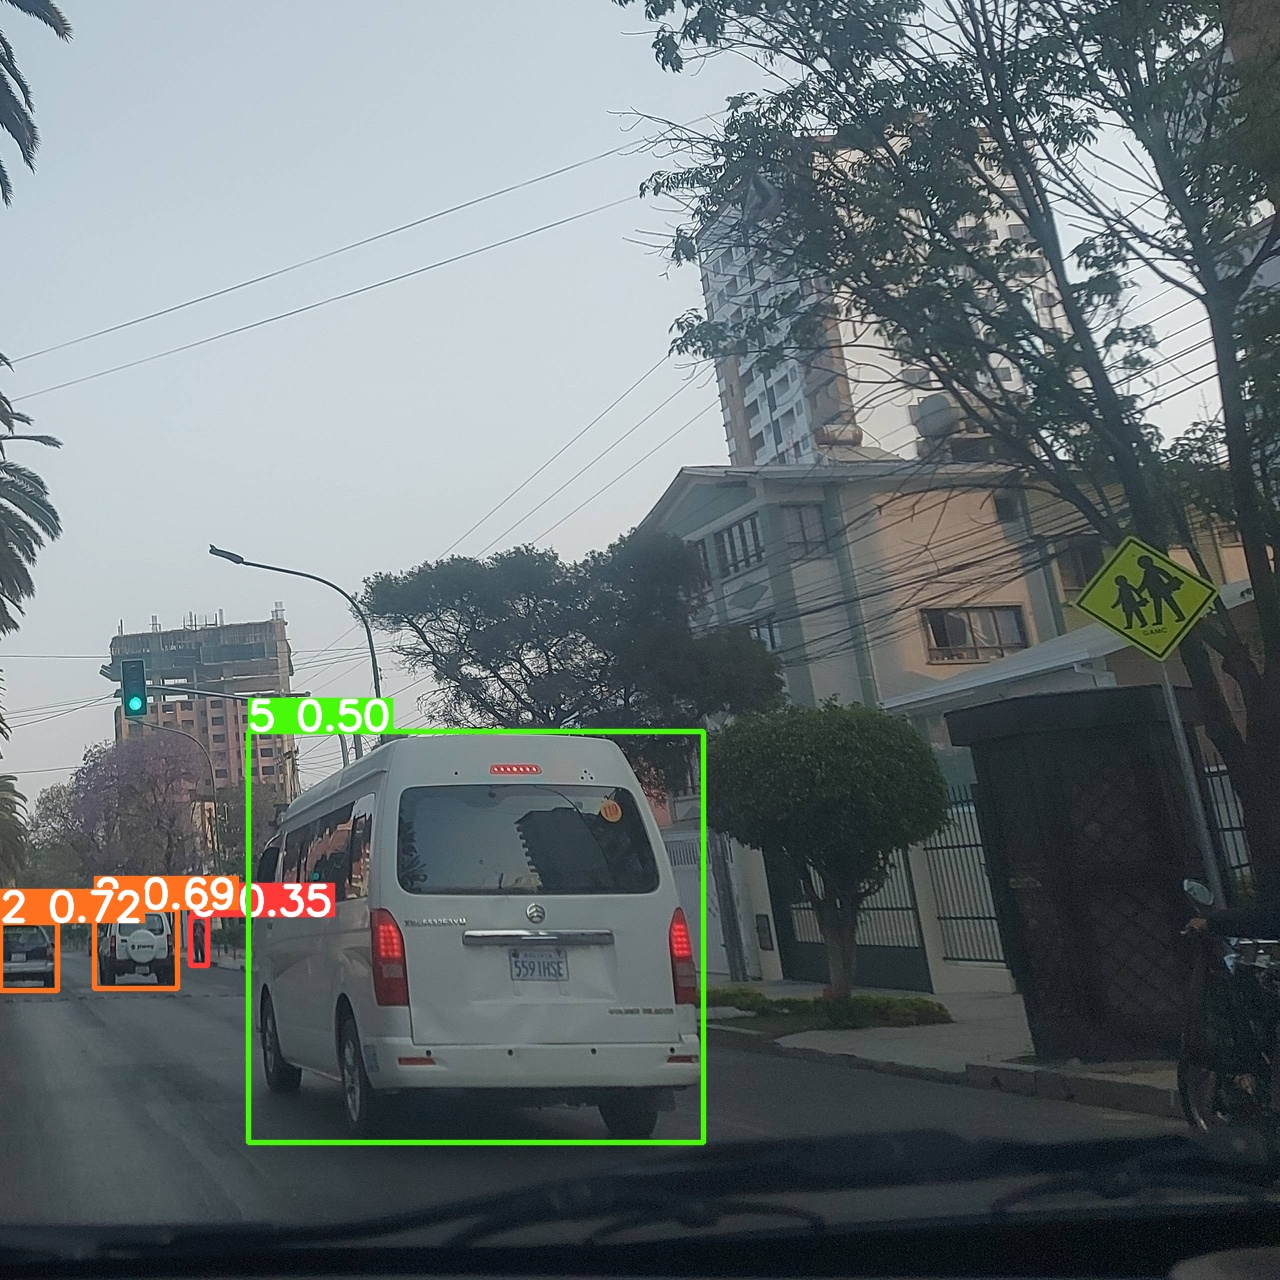

In [11]:
from IPython.display import Image

# Display the detected image
Image(filename=f"{HOME}\\resultados\\YOLOv10\\prueba_inferencia\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

# Entrenamiento con Fine Tuning de YOLOv10 utilizando un conjunto de datos personalizado

In [13]:
import torch
print(torch.cuda.is_available())

True


In [14]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Aug_14_10:26:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.68
Build cuda_12.6.r12.6/compiler.34714021_0


In [15]:
torch.version.cuda

'12.4'

In [16]:
import ultralytics

ultralytics.checks()

Ultralytics YOLOv8.1.34 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
Setup complete ✅ (12 CPUs, 31.9 GB RAM, 929.4/953.0 GB disk)


In [17]:
!pip install albumentations==1.4

In [10]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=10 batch=16 plots=True model={HOME}/weights/yolov10n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 imgsz=640 project="resultados\\YOLOv10" name="10_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


New https://pypi.org/project/ultralytics/8.3.89 available ðŸ˜ƒ Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolov10n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=0, workers=8, project=resultados\\YOLOv10, name=10_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_h

C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\ultralytics\nn\tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cp

In [5]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=10 batch=16 plots=True model={HOME}/weights/yolov10n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 imgsz=640 project="resultados\\YOLOv10" name="10_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\ultralytics\nn\tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cp

New https://pypi.org/project/ultralytics/8.3.89 available ðŸ˜ƒ Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolov10n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=0, workers=8, project=resultados\\YOLOv10, name=10_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_h

In [6]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=300 batch=16 plots=True model={HOME}/weights/yolov10n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 patience=20 imgsz=640 project="resultados\\YOLOv10" name="300_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
New https://pypi.org/project/ultralytics/8.3.89 available ðŸ˜ƒ Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolov10n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=300, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=0, workers=8, project=resultados\\YOLOv10, name=300_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=Tr

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



                   all        235        259      0.828       0.76      0.788      0.595

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size
                   all        235        259      0.823       0.75      0.821      0.595

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size
                   all        235        259       0.87      0.696      0.826      0.608

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size
                   all        235        259      0.814      0.888      0.938      0.669

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size
                   all        235        259      0.849      0.838      0.898      0.647

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       

     37/300      3.04G      1.083       0.61      1.029      1.294     0.6599      1.032         26        640:  55%|#####5    | 169/306 [00:32<00:28,  4.82it/s]
     37/300      3.04G      1.082     0.6097      1.029      1.295     0.6604      1.032         14        640:  55%|#####5    | 169/306 [00:32<00:28,  4.82it/s]
     37/300      3.04G      1.082     0.6097      1.029      1.295     0.6604      1.032         14        640:  56%|#####5    | 170/306 [00:32<00:26,  5.13it/s]
     37/300      3.04G      1.082     0.6097      1.028      1.295     0.6608      1.032         44        640:  56%|#####5    | 170/306 [00:33<00:26,  5.13it/s]
     37/300      3.04G      1.082     0.6097      1.028      1.295     0.6608      1.032         44        640:  56%|#####5    | 171/306 [00:33<00:26,  5.10it/s]
     37/300      3.04G      1.083     0.6093      1.028      1.295     0.6605      1.032         15        640:  56%|#####5    | 171/306 [00:33<00:26,  5.10it/s]
     37/300      3.04G      

# Pruebas de inferencia con el modelo entrenado

In [8]:
!yolo task=detect mode=predict conf=0.25 imgsz=640 save=True show=True model={HOME}\resultados\YOLOv10\300_epochs\weights\best.pt source={HOME}\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\ device=0 project="resultados\\YOLOv10" name="prueba_inferencia_300_epochs" exist_ok=True 

WARNING âš ï¸� Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'

Ultralytics YOLOv8.1.34 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
YOLOv10n summary (fused): 285 layers, 2700266 parameters, 0 gradients, 8.3 GFLOPs

image 1/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_08_18_17_40_52_601_-0400_1280x1280.left-region.jpg: 640x640 1 zona-escolar, 1 prohibido-girar-izquierda, 14.0ms
image 2/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_sign

C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\ultralytics\nn\tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cp

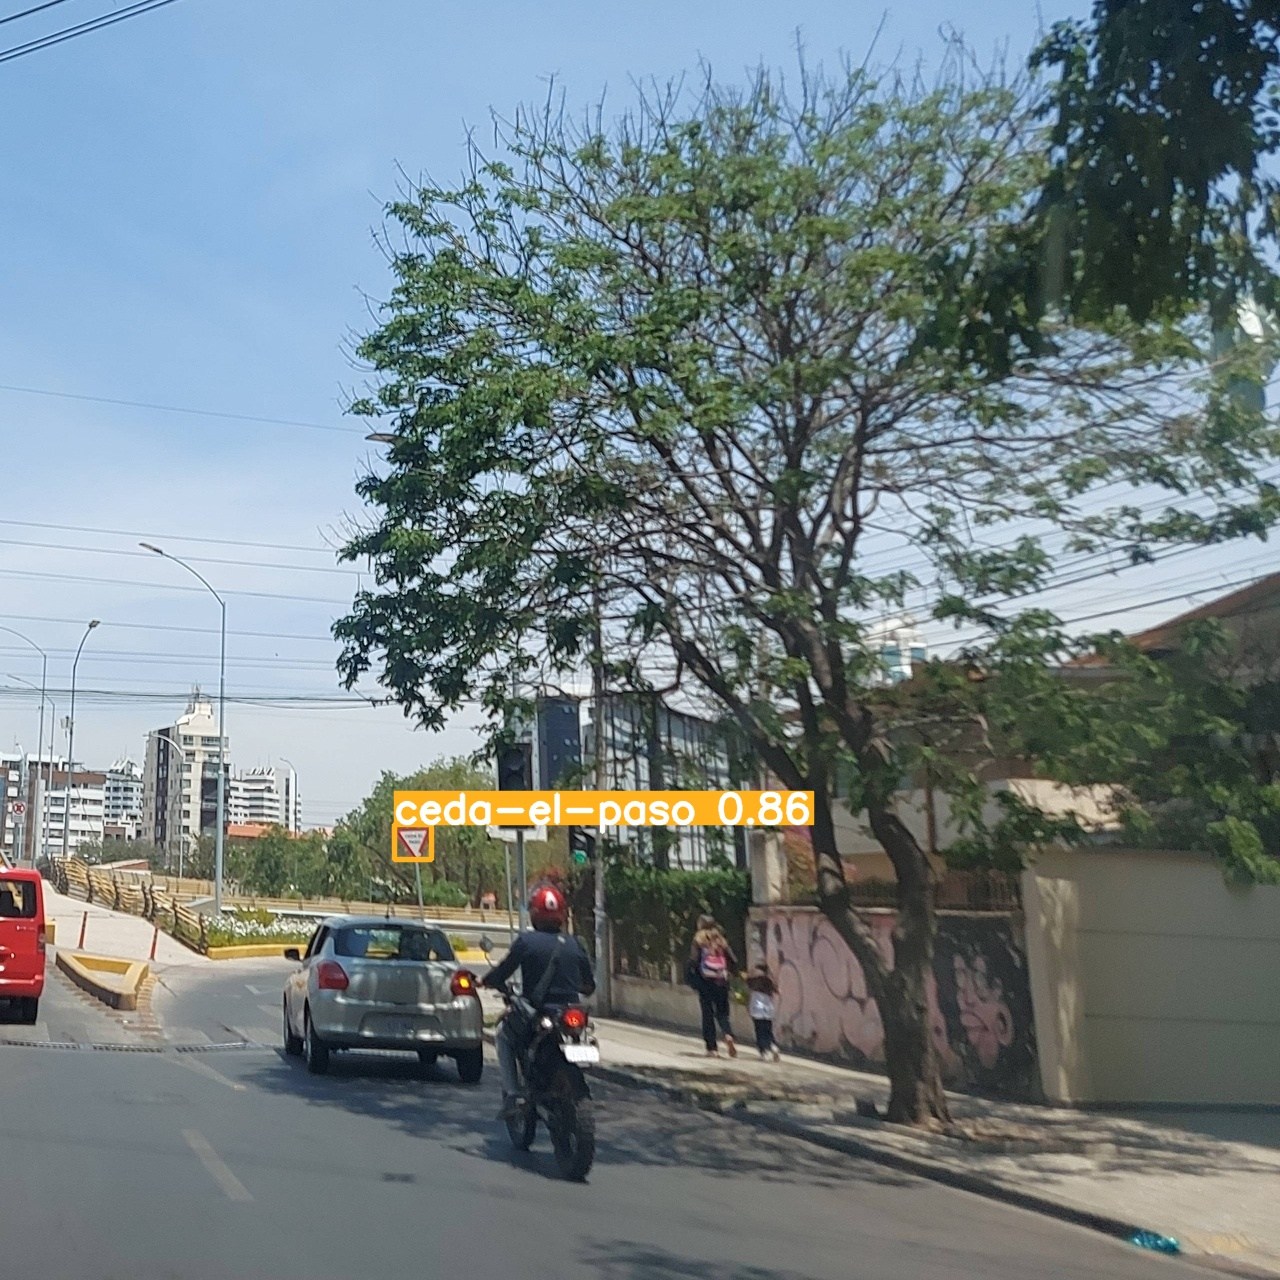

In [9]:
from IPython.display import Image
Image(filename=f"{HOME}\\resultados\YOLOv10\\prueba_inferencia_300_epochs\\2024_10_01_12_40_45_425_-0400_1280x1280.right-region.jpg", height=600)

## Matrices de Confusión

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


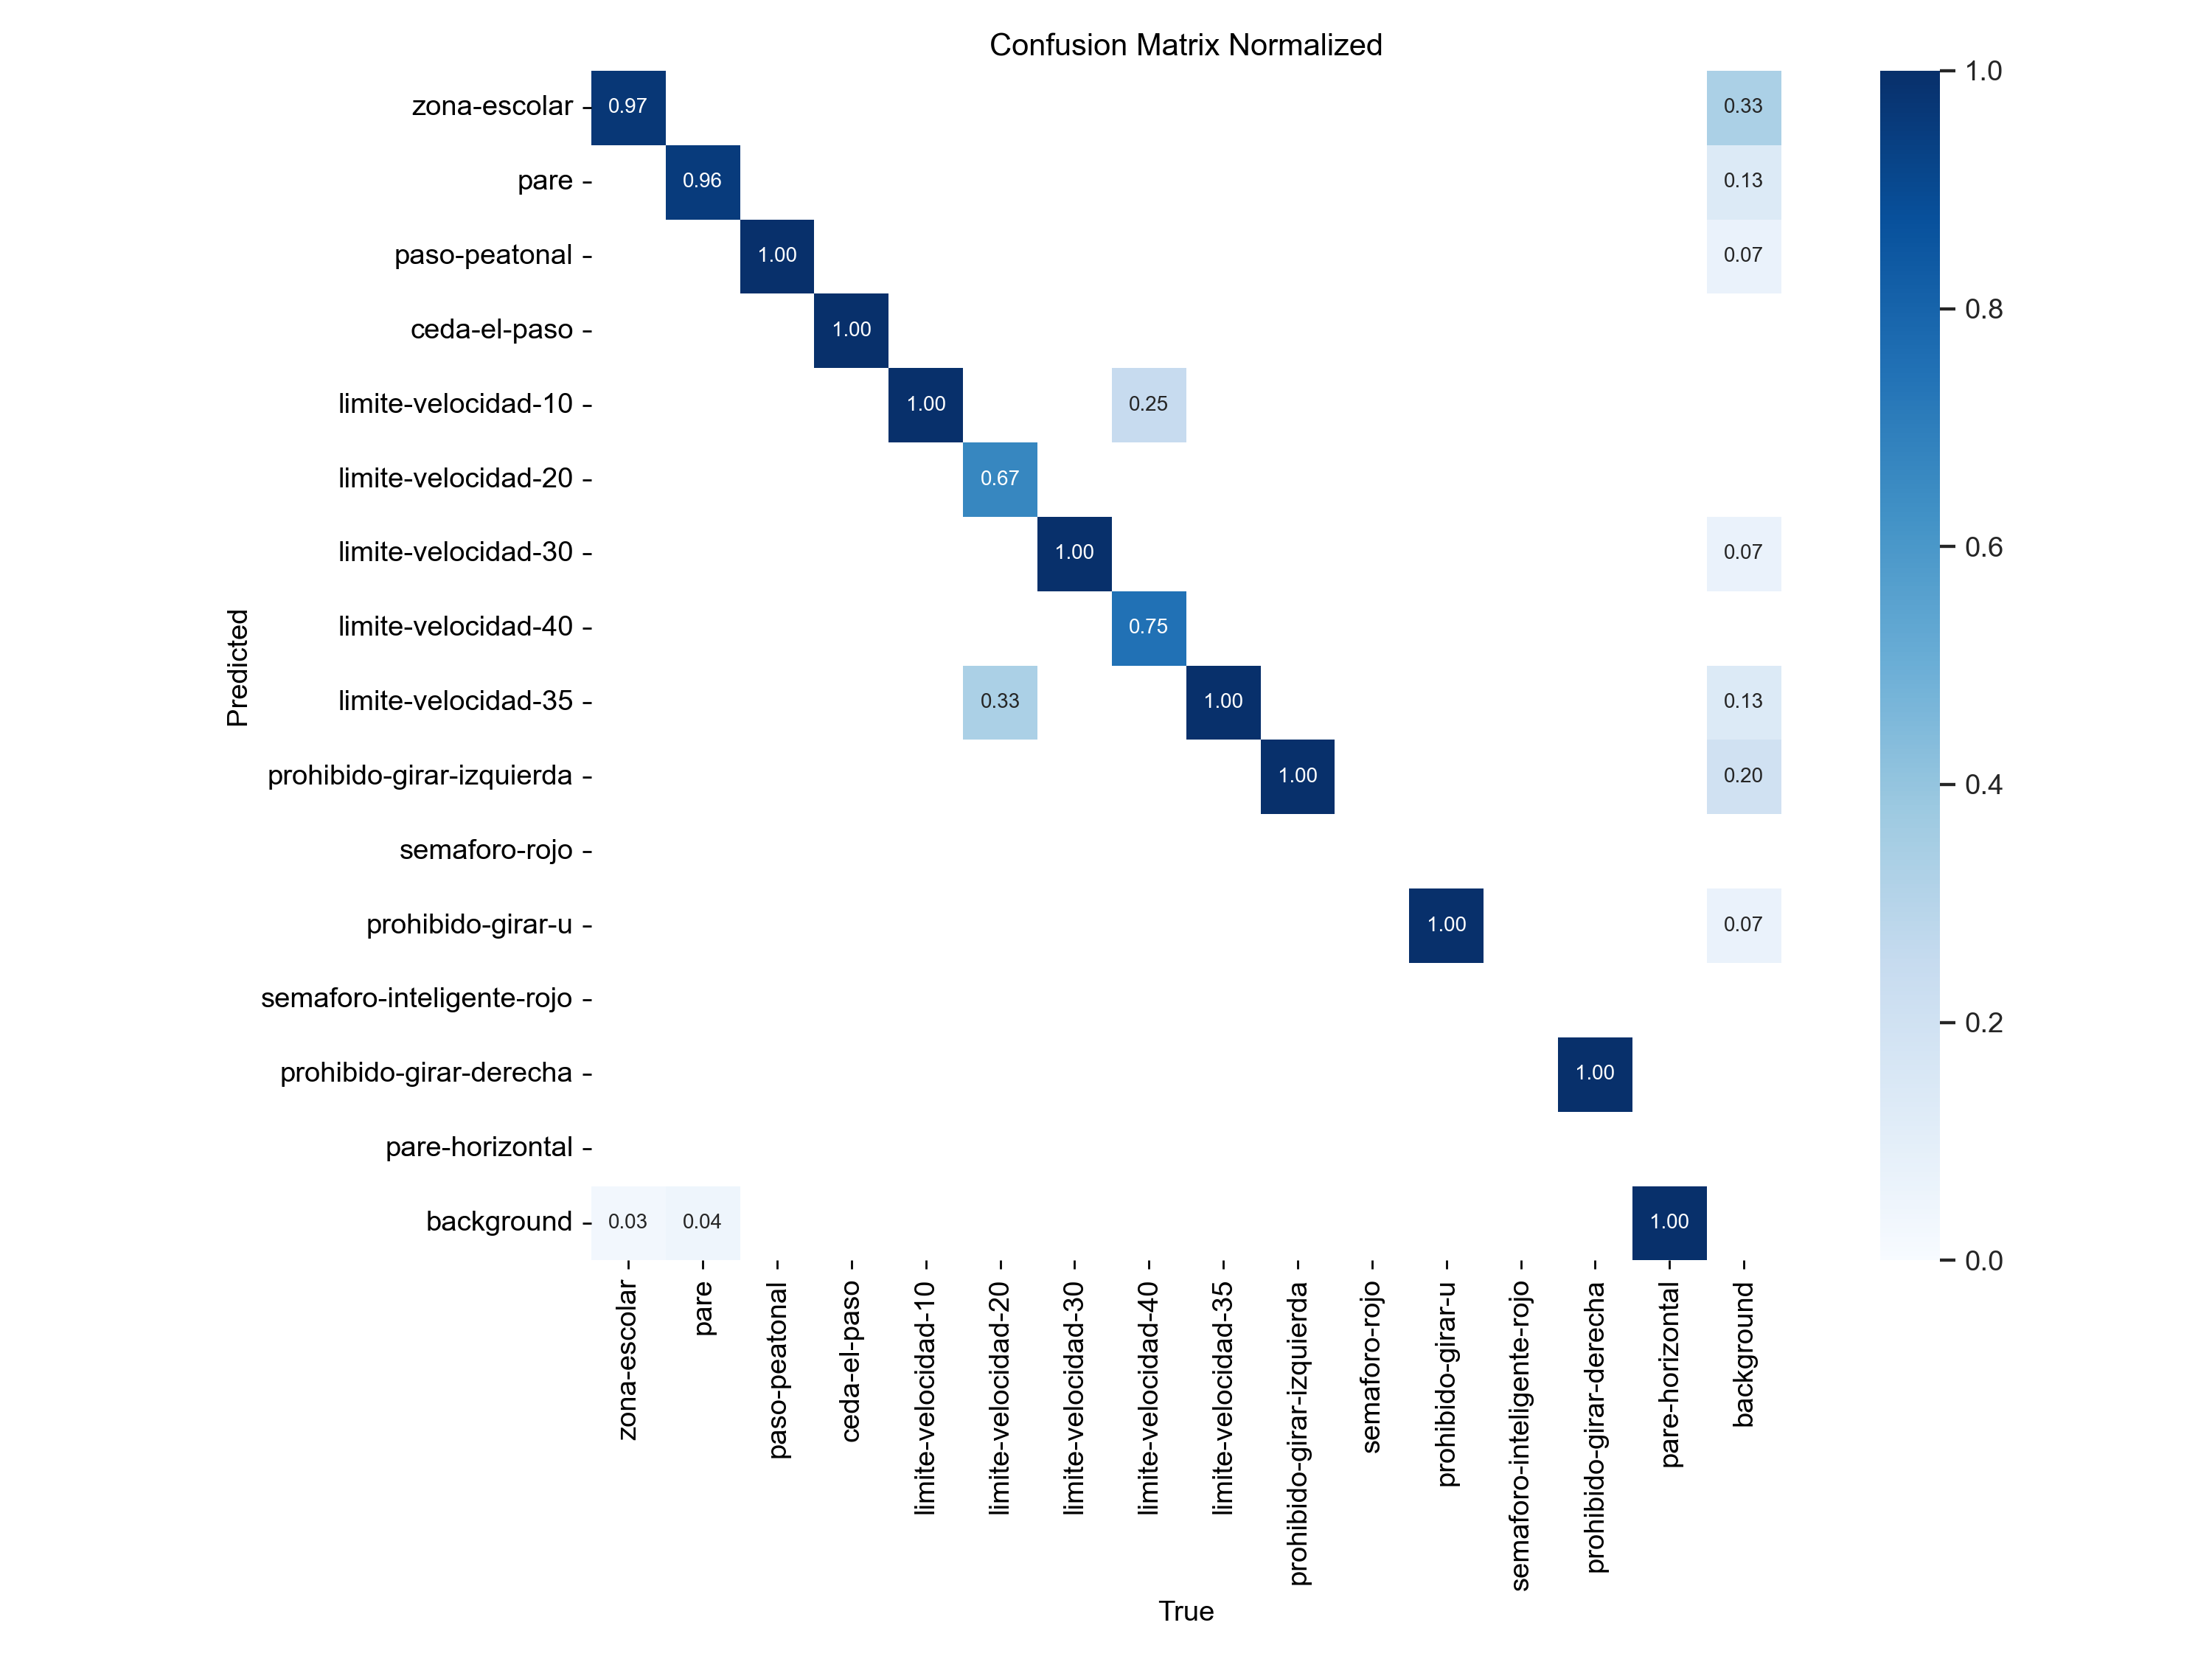

In [10]:
%cd {HOME}
Image(filename=f'{HOME}\\resultados\\YOLOv10\\300_epochs\\confusion_matrix_normalized.png', width=600)


## Exportar el mejor modelo

In [10]:
!pip install --upgrade torch ultralytics onnx2tf

  Using cached torch-2.6.0-cp310-cp310-win_amd64.whl.metadata (28 kB)
  Attempting uninstall: onnx2tf
    Found existing installation: onnx2tf 1.26.3
    Uninstalling onnx2tf-1.26.3:
      Successfully uninstalled onnx2tf-1.26.3


In [11]:
!pip install tensorflow tensorflow-addons

In [13]:
!yolo export model={HOME}/resultados/YOLOv10/300_epochs/weights/best.pt format=tflite

Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.5.1+cu124 CPU (Intel Core(TM) i7-8700 3.20GHz)
YOLOv10n summary (fused): 125 layers, 2,700,266 parameters, 0 gradients, 8.3 GFLOPs

PyTorch: starting from 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv10\300_epochs\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.18.0...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.31...
ONNX: export success âœ… 2.5s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv10\300_epochs\weights\best.onnx' (9.0 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.26.3...
TensorFlow SavedModel: export success âœ… 34.5s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv10\300_epochs\weights\best_saved_model' (23.9 MB


I0000 00:00:1741903433.115703   12676 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1741903433.116679   12676 single_machine.cc:361] Starting new session
W0000 00:00:1741903434.134965   12676 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1741903434.135554   12676 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1741903435.365766   12676 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1741903435.365911   12676 single_machine.cc:361] Starting new session
W0000 00:00:1741903436.265145   12676 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1741903436.265201   12676 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
